![BSC AI Factory — Differential Privacy — Module 4](assets/headers/differential-privacy.jpg)

# 03. Differential privacy

**Topic: Module 4 · Walkthrough: Module 8, slide 5**

Reconstruct a hidden diagnosis column from count queries, repeat the attack with noisy counts, and enforce a cumulative privacy budget.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer.


## Setup

Use a fresh **Python 3.11** environment. The next cell installs missing packages and corrects version mismatches.
If it installs anything, restart the kernel, then run all cells in order. Results are saved under `generated/`.


In [1]:
import subprocess
import sys
from importlib.metadata import version, PackageNotFoundError

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        "This pinned course pack requires Python 3.11. Select a Python 3.11 kernel before installing packages."
    )

REQUIRED = {
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "scipy": "1.13.1",
    "scikit-learn": "1.5.0",
    "matplotlib": "3.9.4",
    "diffprivlib": "0.6.5",
}


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


missing = [
    f"{name}=={wanted}"
    for name, wanted in REQUIRED.items()
    if installed_version(name) != wanted
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
    raise RuntimeError("Setup finished. Restart the kernel/runtime, then Run All.")
print("Dependencies ready:", {name: version(name) for name in REQUIRED})

Dependencies ready: {'numpy': '1.26.4', 'pandas': '2.2.3', 'scipy': '1.13.1', 'scikit-learn': '1.5.0', 'matplotlib': '3.9.4', 'diffprivlib': '0.6.5'}


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)

from sklearn.datasets import load_breast_cancer
from scipy.linalg import pinv
from diffprivlib.mechanisms import Laplace
from diffprivlib import BudgetAccountant
from diffprivlib.utils import BudgetError

OUTPUT_DIR = Path("generated/03_differential_privacy")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Define the query and the privacy unit

The public Wisconsin breast-cancer dataset supplies a realistic binary target: 1 means malignant.
For this exercise, patient slots and cohort membership are known; each patient's diagnosis bit is
private. Neighbouring databases differ in **one diagnosis bit at a fixed slot**. A count over unique
slots therefore has sensitivity 1. This is an attribute-privacy demonstration, not a membership
privacy claim. A Python object in one notebook illustrates the API boundary; it is not an isolated server.


In [3]:
data = load_breast_cancer()
true_diagnoses = (data.target == 0).astype(float)
n_patients = len(true_diagnoses)
print(
    f"Public teaching data: {n_patients} records; {int(true_diagnoses.sum())} malignant labels."
)


class HospitalStatsAPI:
    def __init__(
        self, diagnosis, epsilon_per_query=None, total_epsilon=None, random_state=None
    ):
        self._diagnosis = np.asarray(diagnosis, dtype=float).copy()
        if self._diagnosis.ndim != 1 or not np.isin(self._diagnosis, [0, 1]).all():
            raise ValueError("Expected one binary value per patient.")
        self.n_patients = len(self._diagnosis)
        self.queries = 0
        self.epsilon = epsilon_per_query
        self.accountant = None
        self.mechanism = None
        if self.epsilon is not None:
            if (
                total_epsilon is None
                or not np.isfinite(total_epsilon)
                or total_epsilon <= 0
            ):
                raise ValueError("A finite positive total budget is required.")
            self.accountant = BudgetAccountant(epsilon=float(total_epsilon), delta=0)
            self.mechanism = Laplace(
                epsilon=float(self.epsilon), sensitivity=1.0, random_state=random_state
            )

    def count_malignant(self, patient_ids):
        ids = np.asarray(patient_ids)
        if ids.ndim != 1 or ids.dtype.kind not in "iu":
            raise ValueError("Use a vector of integer IDs.")
        if np.any(ids < 0) or np.any(ids >= self.n_patients):
            raise ValueError("ID outside registry.")
        # Repeated IDs must not multiply one person's contribution.
        ids = np.unique(ids)
        if self.accountant is not None:
            self.accountant.check(self.epsilon, 0)
        count = float(self._diagnosis[ids].sum())
        answer = count
        if self.mechanism is not None:
            answer = self.mechanism.randomise(count)
        if self.accountant is not None:
            self.accountant.spend(self.epsilon, 0)
        self.queries += 1
        return answer


assert HospitalStatsAPI([1, 0]).count_malignant([0, 0, 0]) == 1

Public teaching data: 569 records; 212 malignant labels.


## 2. Attack the exact-count API

Each row of `query_matrix` describes a random cohort. Its answer is one linear equation in the unknown diagnosis
bits. With enough independent equations, least squares can recover those bits without an API ever
returning an individual record. The attacker uses only cohort definitions and returned answers;
`true_diagnoses` is used separately to score the attack.


In [4]:
QUERY_MULTIPLIER = 2
n_queries = QUERY_MULTIPLIER * n_patients
query_rng = np.random.default_rng(0)
query_matrix = query_rng.integers(0, 2, size=(n_queries, n_patients)).astype(float)
cohorts = [np.flatnonzero(row).astype(int) for row in query_matrix]
query_pseudoinverse, rank = pinv(query_matrix, return_rank=True)
assert rank == n_patients, "Need enough independent queries for exact reconstruction."


def query_answers(api):
    return np.array([api.count_malignant(ids) for ids in cohorts])


def reconstruct(answers):
    """Solve the count equations, then round each estimated diagnosis to 0 or 1."""
    estimated_diagnoses = query_pseudoinverse @ answers
    return (estimated_diagnoses >= 0.5).astype(float)


exact_api = HospitalStatsAPI(true_diagnoses)
exact_answers = query_answers(exact_api)
exact_guess = reconstruct(exact_answers)
exact_accuracy = float((exact_guess == true_diagnoses).mean())
assert exact_accuracy == 1 and exact_api.queries == n_queries
majority_baseline = max(true_diagnoses.mean(), 1 - true_diagnoses.mean())
print(
    f"Exact API: {n_queries} queries, {exact_accuracy:.1%} diagnosis values reconstructed."
)
print(f"Always guessing the majority class: {majority_baseline:.1%}.")

Exact API: 1138 queries, 100.0% diagnosis values reconstructed.
Always guessing the majority class: 62.7%.


## 3. Add Laplace noise and measure the same attack

Keep `query_matrix` fixed so all runs use the same questions. Smaller epsilon per query adds more noise.
The table also reports the **composed epsilon for the whole attack**, using the conservative sum.
A small per-query epsilon can still become a large total after many releases.

The seeds below are only for reproducible experiments on public data. For sensitive data, use
`random_state=None` and one persistent accountant shared across every release. Recreating an API
does not reset the real privacy cost. The separate trials and settings here are experimental comparisons,
not multiple free releases from a private dataset. The majority baseline uses public evaluation labels.


,epsilon_per_query,queries,composed_epsilon,reconstruction_percent,trial_std_percent,count_mean_absolute_error
0,0.02,1138,22.76,54.446,1.955,50.055
1,0.05,1138,56.90,58.489,2.182,20.022
2,0.10,1138,113.80,66.257,1.291,10.011
3,0.20,1138,227.60,80.105,0.827,5.006
4,0.30,1138,341.40,89.561,1.869,3.337
5,0.50,1138,569.00,97.891,0.882,2.002
6,1.00,1138,1138.00,100.000,0.000,1.001


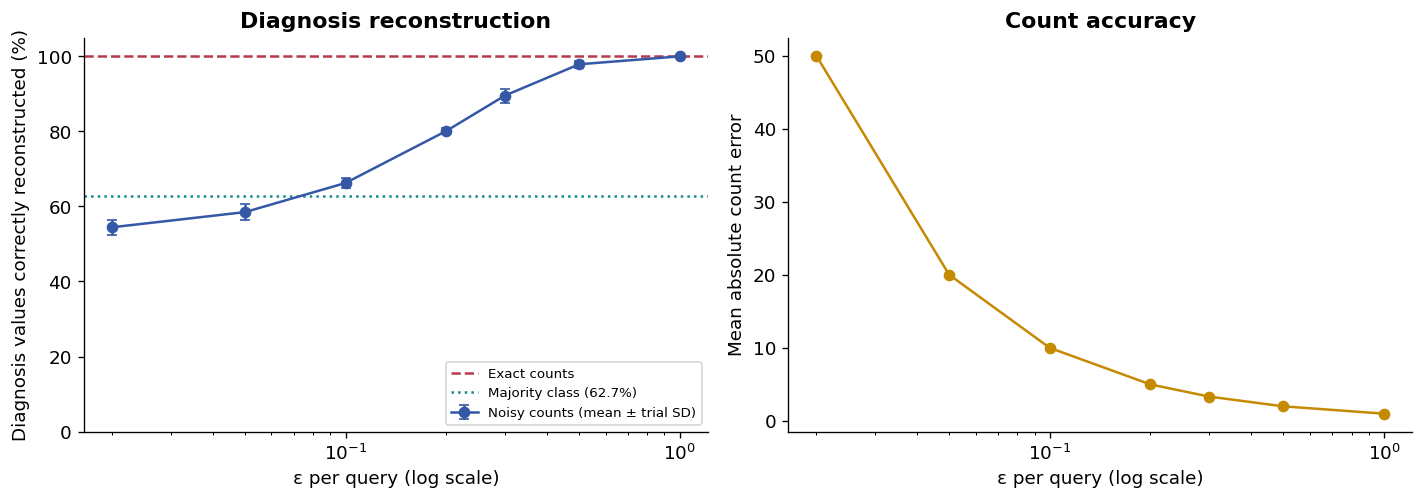

In [5]:
EPSILONS = [0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
TRIALS = 5
rows = []
for epsilon in EPSILONS:
    trial_accuracies, trial_count_errors = [], []
    for trial in range(TRIALS):
        # A tiny tolerance avoids floating-point accumulation at the budget boundary.
        api = HospitalStatsAPI(
            true_diagnoses,
            epsilon_per_query=epsilon,
            total_epsilon=n_queries * epsilon + 1e-9,
            random_state=100 + trial,
        )
        answers = query_answers(api)
        trial_accuracies.append(
            100 * float((reconstruct(answers) == true_diagnoses).mean())
        )
        trial_count_errors.append(float(np.mean(np.abs(answers - exact_answers))))
        assert api.queries == n_queries and np.isclose(
            api.accountant.total()[0], n_queries * epsilon
        )
    rows.append(
        {
            "epsilon_per_query": epsilon,
            "queries": n_queries,
            "composed_epsilon": n_queries * epsilon,
            "reconstruction_percent": np.mean(trial_accuracies),
            "trial_std_percent": np.std(trial_accuracies),
            "count_mean_absolute_error": np.mean(trial_count_errors),
        }
    )
results = pd.DataFrame(rows)
display(results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].errorbar(
    results.epsilon_per_query,
    results.reconstruction_percent,
    yerr=results.trial_std_percent,
    marker="o",
    capsize=3,
    color=BLUE,
    label="Noisy counts (mean ± trial SD)",
)
axes[0].axhline(100, color=RED, ls="--", label="Exact counts")
axes[0].axhline(
    100 * majority_baseline,
    color=TEAL,
    ls=":",
    label=f"Majority class ({majority_baseline:.1%})",
)
axes[0].set(
    xscale="log",
    ylim=(0, 105),
    xlabel="ε per query (log scale)",
    ylabel="Diagnosis values correctly reconstructed (%)",
    title="Diagnosis reconstruction",
)
axes[0].legend(fontsize=8, loc="lower right")
axes[1].plot(
    results.epsilon_per_query, results.count_mean_absolute_error, "o-", color=GOLD
)
axes[1].set(
    xscale="log",
    xlabel="ε per query (log scale)",
    ylabel="Mean absolute count error",
    title="Count accuracy",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "reconstruction_and_utility.png", bbox_inches="tight")
plt.show()
results.to_csv(OUTPUT_DIR / "epsilon_sweep.csv", index=False)

## 4. Refuse a query before it exceeds the budget

This API has a total epsilon of 1.0 and charges 0.25 for each response. The fifth request must be
refused before reading the diagnosis vector or releasing an answer. The mechanism protects each
bounded release; it does not promise that every attack fails or that output distributions are identical.


In [6]:
limited_api = HospitalStatsAPI(
    true_diagnoses, epsilon_per_query=0.25, total_epsilon=1.0, random_state=19
)
for _ in range(4):
    limited_api.count_malignant(np.arange(50))
before_queries, before_budget = limited_api.queries, limited_api.accountant.total()
try:
    limited_api.count_malignant(np.arange(50))
except BudgetError:
    print("Fifth query refused before release.")
else:
    raise AssertionError("Budget limit was not enforced.")
assert (
    limited_api.queries == before_queries == 4
    and limited_api.accountant.total() == before_budget
)
summary = {
    "patients": n_patients,
    "queries_per_attack": n_queries,
    "exact_reconstruction": exact_accuracy,
    "majority_baseline": float(majority_baseline),
    "refusal_checked": True,
    "privacy_unit": "one diagnosis bit in a fixed public patient slot",
}
(OUTPUT_DIR / "checks.json").write_text(json.dumps(summary, indent=2))
print(
    "Checks passed: exact recovery, unique-ID sensitivity, budget accounting and refusal."
)

Fifth query refused before release.
Checks passed: exact recovery, unique-ID sensitivity, budget accounting and refusal.


## Experiments

1. Increase `QUERY_MULTIPLIER` and compare attack accuracy **and total epsilon**.
2. Hold total epsilon fixed and divide it by the number of questions before rerunning the attack.
3. Change the cohort density from 50% and compare the rank and conditioning of `query_matrix`.

References: [diffprivlib mechanisms](https://diffprivlib.readthedocs.io/en/latest/modules/mechanisms.html),
[budget accounting](https://diffprivlib.readthedocs.io/en/latest/modules/accountant.html),
[Dwork and Roth, The Algorithmic Foundations of Differential Privacy](https://www.cis.upenn.edu/~aaroth/Papers/privacybook.pdf).
